# Telecom Marketing Campaign Optimisation Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
from statsmodels.graphics.factorplots import interaction_plot
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,classification_report, f1_score
from sklearn.metrics import roc_auc_score, make_scorer

import warnings 
warnings.filterwarnings('ignore')

# DATA LOADING

In [2]:
#READ the file 
with open("TeleCom_Data.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

In [3]:
rows = []

for line in lines:
    line = line.strip().replace('""', '"').strip('"') 
    split_line = line.split(';')                         
    rows.append(split_line)

print("Number of rows:", len(rows))

Number of rows: 41181


In [4]:
# Separate header and data
header = [col.strip('"') for col in rows[0]]  # Remove quotes from column names
data = rows[1:]
print("Number of columns:", len(header))

Number of columns: 21


In [5]:
df = pd.DataFrame(data, columns=header)
df = df.applymap(lambda x: x.strip('"') if isinstance(x, str) else x)

df.columns.unique()

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

`Balance` missing from dictionary

In [6]:
numeric_cols = [
    'age', 'duration', 'campaign', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed', 'pdays'
]

# Convert using pandas to_numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# DATA EXPLORATION

In [7]:
pd.set_option('display.max_columns', None)
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41180 entries, 0 to 41179
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41180 non-null  int64  
 1   job             41180 non-null  object 
 2   marital         41180 non-null  object 
 3   education       41180 non-null  object 
 4   default         41180 non-null  object 
 5   housing         41180 non-null  object 
 6   loan            41180 non-null  object 
 7   contact         41180 non-null  object 
 8   month           41180 non-null  object 
 9   day_of_week     41180 non-null  object 
 10  duration        41180 non-null  int64  
 11  campaign        41180 non-null  int64  
 12  pdays           41180 non-null  int64  
 13  previous        41180 non-null  int64  
 14  poutcome        41180 non-null  object 
 15  emp.var.rate    41180 non-null  float64
 16  cons.price.idx  41180 non-null  float64
 17  cons.conf.idx   41180 non-null 

In [9]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000
mean,40.021710,258.280427,2.567800,962.516707,0.172705,0.081901,93.575508,-40.501999,3.621422,5167.053344
std,10.419593,259.299856,2.770225,186.809028,0.493719,1.571037,0.578762,4.627358,1.734385,72.230334
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Non of the numerical values seems out of the ordinary. 

# DATA CLEANING
## Duplicates

In [10]:
# Checking for duplicates

def check_duplicates(dataset):
    """Check for duplicate rows in the dataset and print the number of duplicates."""
    duplicates = dataset.duplicated().sum()  # Count the number of duplicate rows

    if dataset.empty:
        print("The dataset is empty.")
    elif duplicates > 0:
        print(f"Number of duplicate rows: {duplicates}")
        print(f"The percentage of duplicate rows: {duplicates / len(dataset) * 100:.2f}%")
    else:
        print("The dataset is not empty and has no duplicate rows.")

# Call the function to check for duplicates
check_duplicates(df)

Number of duplicate rows: 12
The percentage of duplicate rows: 0.03%


In [11]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1262,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12257,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14230,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16952,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,43,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18461,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,128,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20212,55,services,married,high.school,unknown,no,no,cellular,aug,mon,33,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20530,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,127,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25213,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,123,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28473,24,services,single,high.school,no,yes,no,cellular,apr,tue,114,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32512,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,348,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [12]:
# Since duplicates are found but only 0.03%, we can drop them
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {df.shape[0]}")
check_duplicates(df)

Number of rows after removing duplicates: 41168
The dataset is not empty and has no duplicate rows.


## Handling missing values

In [13]:
missing_values = df.isnull().sum()
print(missing_values)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


### `unknown` entries in categorical variables

In [14]:
unknown_summary = pd.DataFrame({
    "unknown_count": (df == "unknown").sum(),
    'unknown percentage': ((df == "unknown").mean() * 100).round(2)})

print(unknown_summary[unknown_summary['unknown_count'] > 0])

           unknown_count  unknown percentage
job                  330                0.80
marital               80                0.19
education           1730                4.20
default             8595               20.88
housing              990                2.40
loan                 990                2.40


I want to know if there is a statistical significance between the target variable `y` and the `unknown` values in each of the missing variables.

Therefore, a chi^2 contingency test was conducted to see if there is a difference.
- $H_0$: There is no association between `y` and having `unknown` in the variables
- $H_1$: There is an association between `y` and having `unknown` in the variables

In [15]:
for col in ['education', 'default', 'housing', 'loan', 'marital', 'job']:
    ct = pd.crosstab(df[col] == 'unknown', df['y'])
    chi2, p, dof, ex = chi2_contingency(ct, correction=False)
    print(f"{col}: p-value = {p:.4f}")

education: p-value = 0.0000
default: p-value = 0.0000
housing: p-value = 0.6463
loan: p-value = 0.6463
marital: p-value = 0.2900
job: p-value = 0.9763


The $Chi^2$ results show we can reject the null hypothesis for `education` and `default` variables. Meaning, there is an association between having unknown in the variables and the target variable `y`. Therefore, we should keep the `unknown` values for the 2 variables and imputate the values for the others.


### `default` missing values

- Missingness is too high — imputing would introduce a lot of artificial data and bias results.
- The p-value between is statistically significant ($p<0.05$)
So we treat `unknown` as its own category

### `housing` and `loan` missing values
Why does housing and loan have the same no of missing values? Are they the same info? Is it the same customers with missing loan and housing values? 

In [16]:
mask_housing = df['housing'] == "unknown"
mask_loan = df['loan'] == "unknown"

print((mask_housing == mask_loan).all())  # True if identical rows

True


In [17]:
missing_loans = df[(df['housing'] == 'unknown') & (df['loan'] == 'unknown')]

# Looking at numerical columns for misisng loans
print("Summary statistics for numeric columns:")
missing_loans.describe()

Summary statistics for numeric columns:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,39.951515,250.194949,2.560606,964.896970,0.184848,0.113434,93.636011,-40.289192,3.653046,5166.457273
std,10.381776,254.858555,2.949844,180.927175,0.527478,1.588155,0.601701,4.565782,1.740501,73.202491
min,17.000000,7.000000,1.000000,2.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,169.000000,2.000000,999.000000,0.000000,1.100000,93.918000,-41.800000,4.857000,5191.000000
75%,47.000000,304.250000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,86.000000,2926.000000,56.000000,999.000000,4.000000,1.400000,94.767000,-26.900000,5.000000,5228.100000


In [18]:
# Frequency counts for categorical columns
categorical_cols = [
    col for col in df.columns
    if df[col].dtype == 'object' and col not in ['housing', 'loan']
]

print("\nValue counts for categorical columns:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(missing_loans[col].value_counts())


Value counts for categorical columns:

--- job ---
job
blue-collar      240
admin.           227
technician       147
services         101
management        71
retired           44
self-employed     40
entrepreneur      36
housemaid         29
unemployed        27
student           23
unknown            5
Name: count, dtype: int64

--- marital ---
marital
married     588
single      280
divorced    121
unknown       1
Name: count, dtype: int64

--- education ---
education
university.degree      277
high.school            220
basic.9y               151
professional.course    125
basic.4y               117
basic.6y                60
unknown                 40
Name: count, dtype: int64

--- default ---
default
no         763
unknown    227
Name: count, dtype: int64

--- contact ---
contact
cellular     561
telephone    429
Name: count, dtype: int64

--- month ---
month
may    350
jun    175
jul    147
aug    130
nov     76
apr     58
oct     20
sep     16
mar     12
dec      6
Name: coun

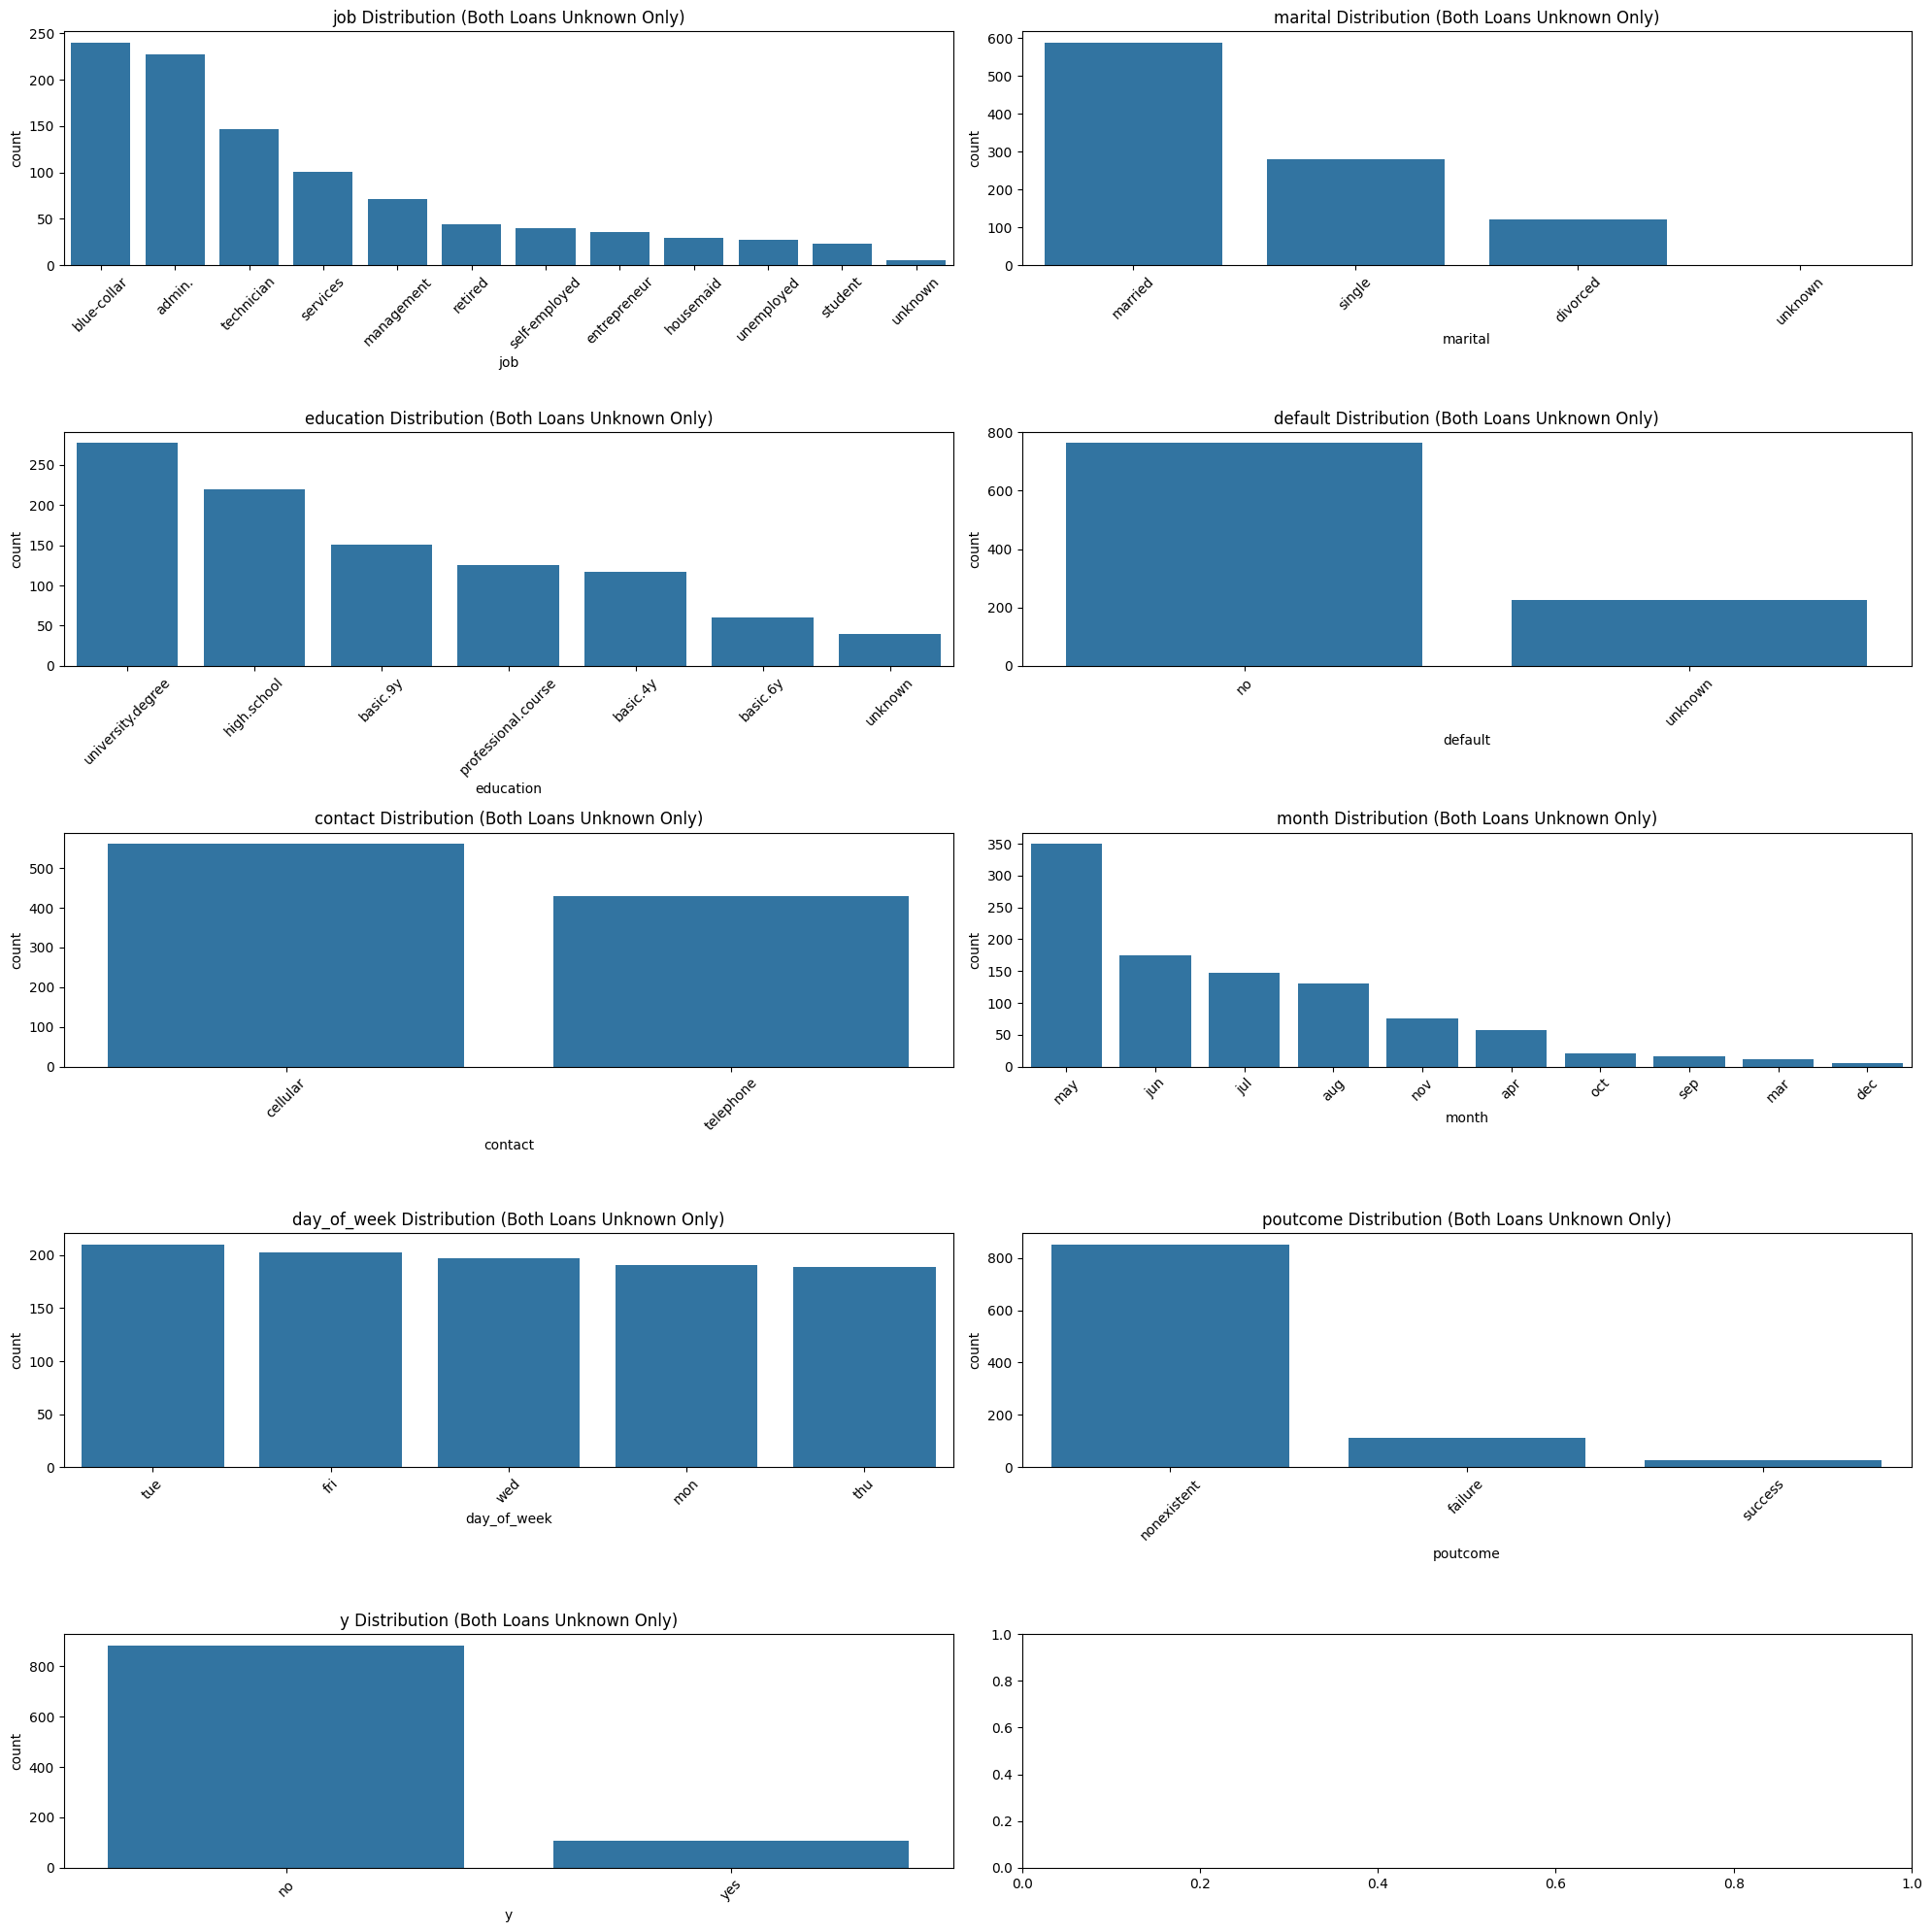

In [19]:
df['missing_loans'] = np.where(
    (df['housing'] == 'unknown') & (df['loan'] == 'unknown'),
    'both_unknown',
    'known'
)
df_unknown = df[df['missing_loans'] == 'both_unknown']

order = {}

figs, axes = plt.subplots(5, 2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order[col] = df_unknown[col].value_counts().index
    sns.countplot(data=df_unknown, x=col, order=order[col], ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f"{col} Distribution (Both Loans Unknown Only)")
    
plt.tight_layout()
plt.show()



- Only people with `default = no/unknown` have unknown loan
- Customers with missing loan information (both housing and personal loan unknown) may form a distinct segment, possibly due to incomplete credit profiling, and their response behavior (y) could differ from other groups.

Therefore, we keep the `unknown` values and treat them as a new group, since it might behave differently or in correlation to other variables

### `Job` and `Marital` missing values
- The percentage of "unknown" values in job (0.8%) and marital (0.19%) is very small.
- Chi-square p-value >0.05 so theres no statistical evidence that 'unknown' relates to target y
- Dropping these rows would unnecessarily reduce the dataset size without a meaningful gain in data quality.
- Therefore, mode imputation was chosen: replacing "unknown" with the most frequent value in each column preserves nearly all the data and maintains category consistency.

In [20]:
df['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [21]:
df['job'] = df['job'].replace('unknown', df['job'].mode()[0])
df['marital'] = df['marital'].replace('unknown', df['marital'].mode()[0])

### `education` unknown values

In [22]:
education_unknown = df[df['education'] == 'unknown']
education_unknown.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000,1730.000000
mean,43.485549,262.491329,2.597110,942.798266,0.226590,0.058324,93.658465,-39.876185,3.570291,5159.509884
std,12.490740,244.758315,2.722588,229.417595,0.623975,1.650771,0.608546,4.695695,1.814315,81.444662
min,17.000000,5.000000,1.000000,1.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,35.000000,105.000000,1.000000,999.000000,0.000000,-1.800000,93.200000,-42.700000,1.327000,5099.100000
50%,43.000000,188.000000,2.000000,999.000000,0.000000,1.100000,93.918000,-41.800000,4.857000,5191.000000
75%,52.000000,326.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,92.000000,2062.000000,29.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


Is there a pattern for missing education entries?

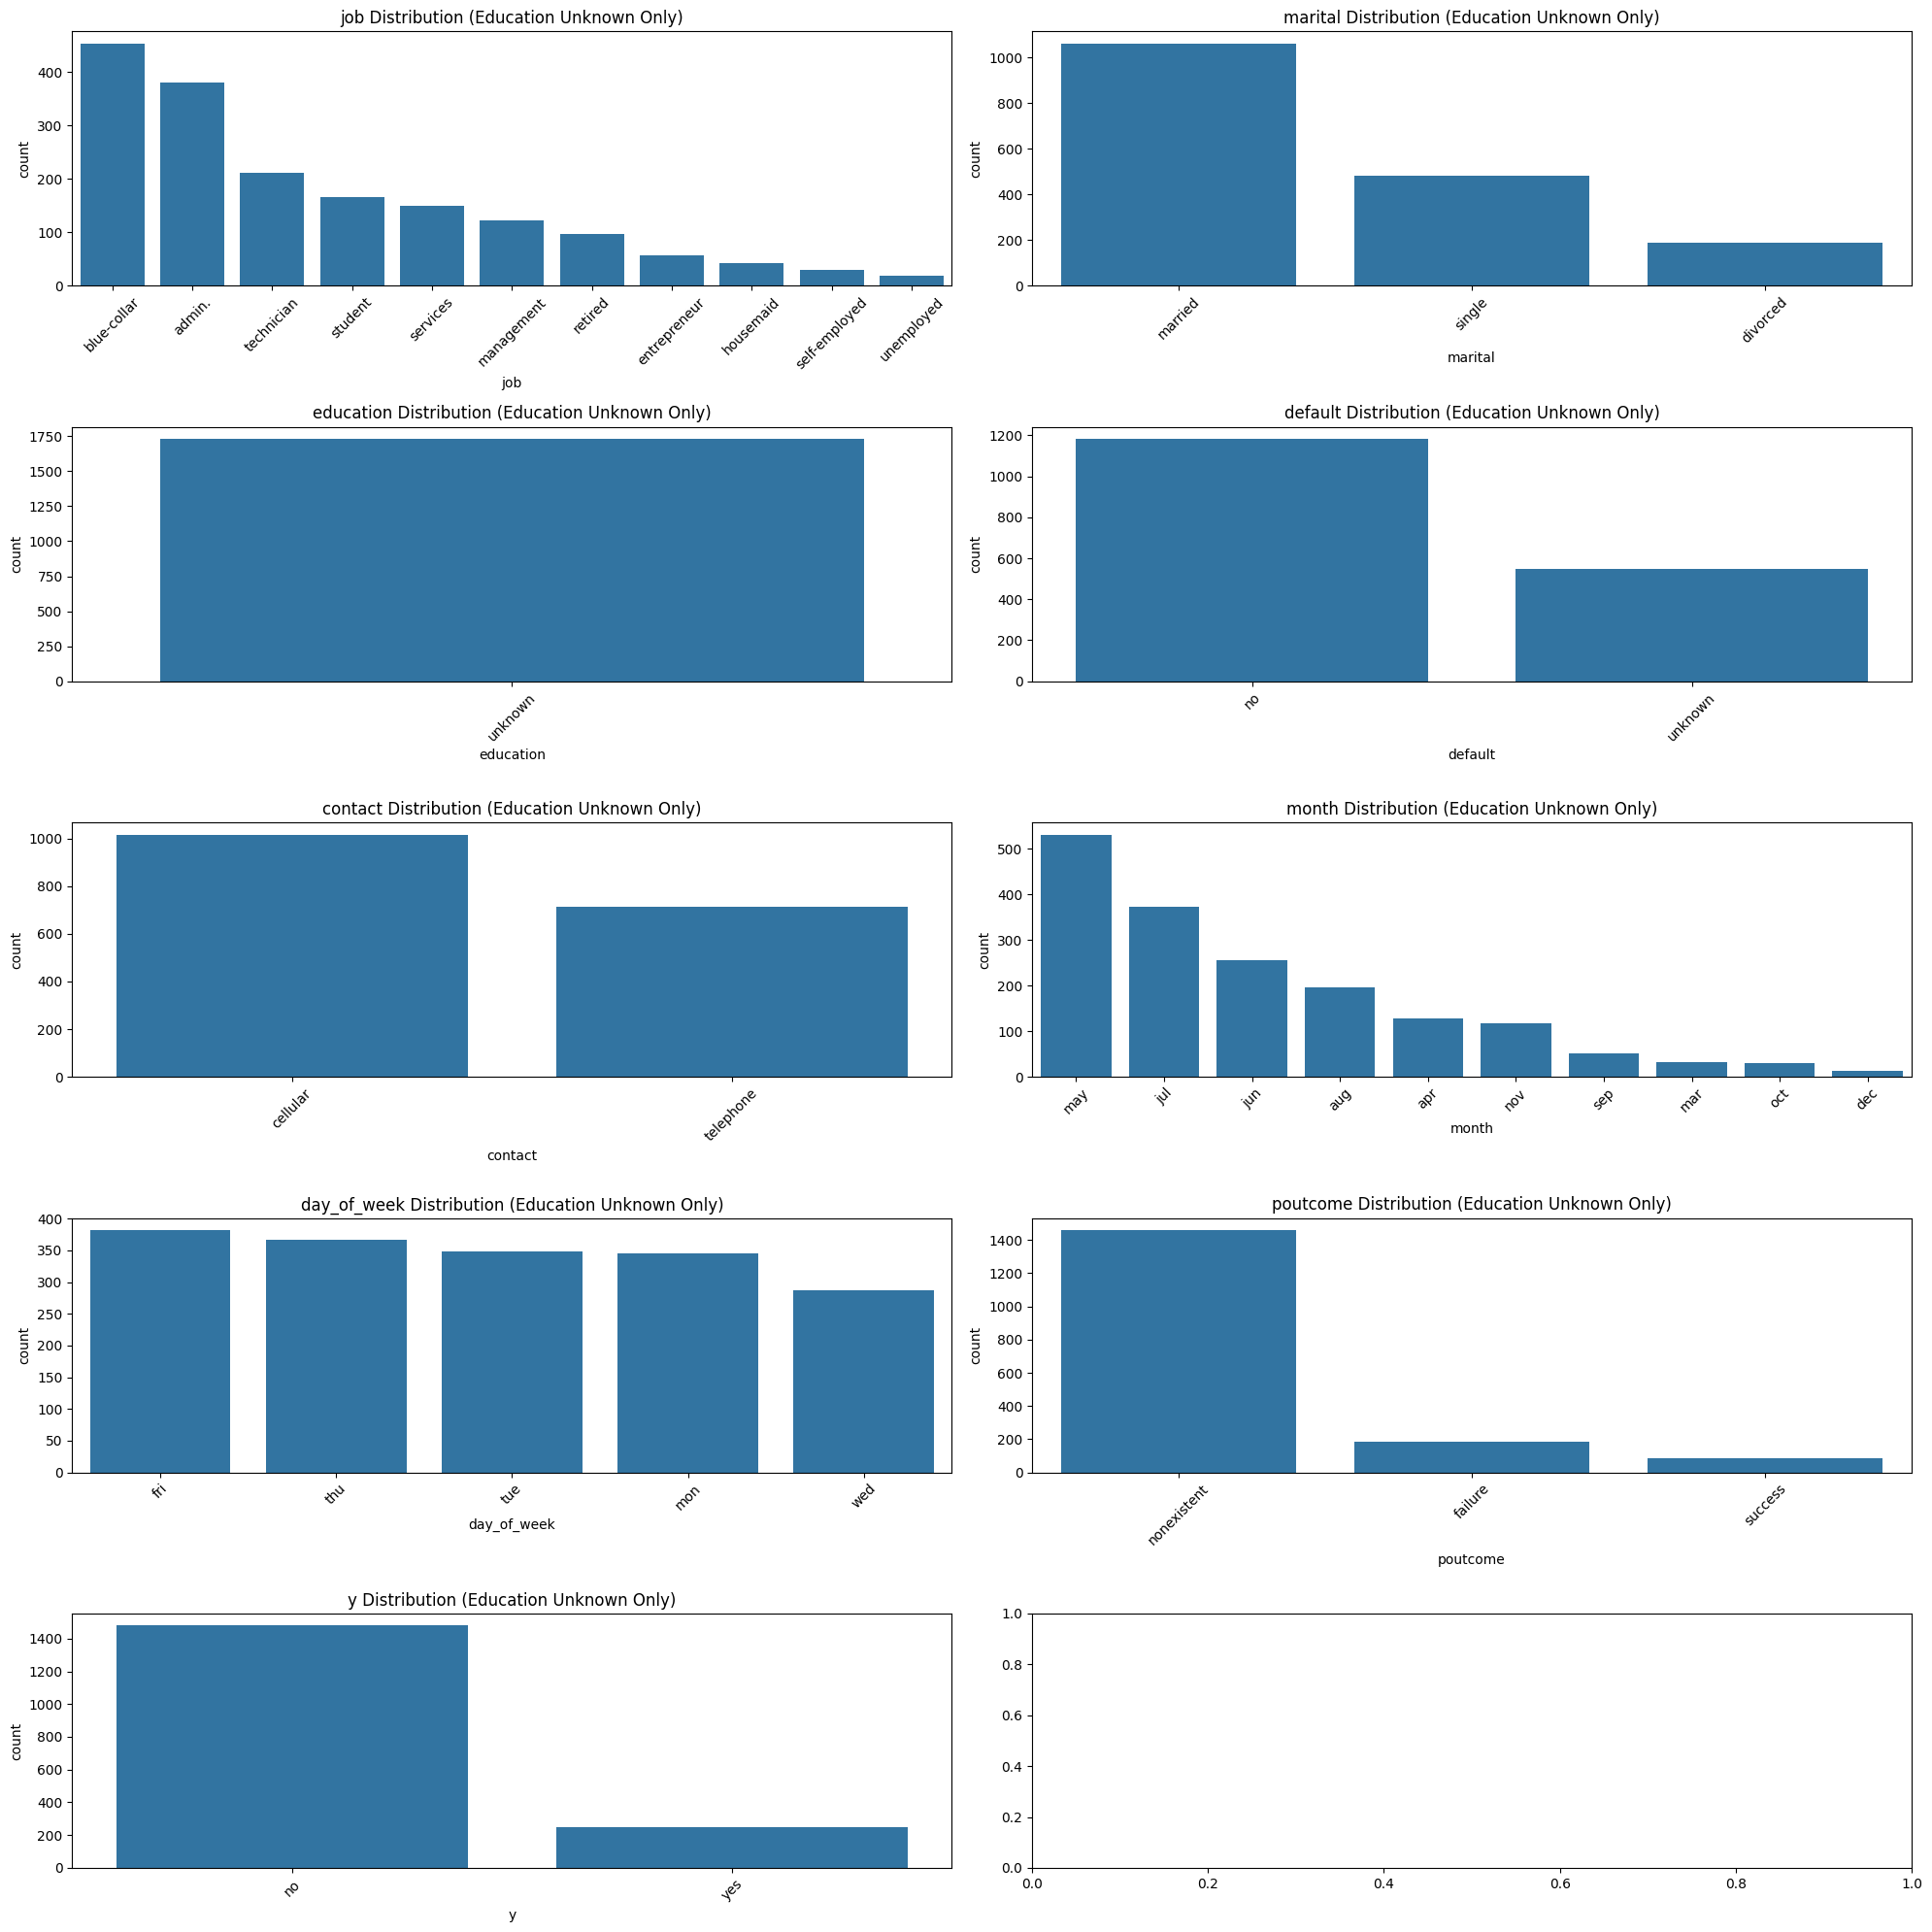

In [23]:

df_unknown = df[df['education'] == 'unknown']

order = {}

figs, axes = plt.subplots(5, 2, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order[col] = df_unknown[col].value_counts().index
    sns.countplot(data=df_unknown, x=col, order=order[col], ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f"{col} Distribution (Education Unknown Only)")
    
plt.tight_layout()
plt.show()



- There's not really any relationship between unknown `education` and other featuress
- A chi-square test showed p < 0.0001, meaning the proportion of y = yes vs. y = no is significantly different for "unknown" compared to known education levels.
- This means the missingness in education is not random — it carries predictive information about the target.
- Imputing would remove this signal, potentially reducing model performance.
- Keeping "unknown" as its own category lets the model learn any patterns tied to people who did not disclose their education level.

In [24]:
unknown_summary = pd.DataFrame({
    "unknown count": (df == "unknown").sum(),
    'unknown percentage': ((df == "unknown").mean() * 100).round(2)})

print(unknown_summary[unknown_summary['unknown count'] > 0])

           unknown count  unknown percentage
education           1730                4.20
default             8595               20.88
housing              990                2.40
loan                 990                2.40


In the end, we dealt with missing data in the following way
- For `loan`, `housing`, `default` and `education`: the unknown values will be treated as its own category
- For `job` and `marital`: the unknown values were imputed with the mode

---
# Feature engineering

In [25]:
df['economic_pressure'] = (
    df['euribor3m'] * -1 * df['cons.conf.idx']  # higher pressure when rates high and confidence low
)

df.drop(columns=['nr.employed', 'emp.var.rate', 'duration', 'cons.conf.idx', 'euribor3m'], inplace=True)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,cons.price.idx,y,missing_loans,economic_pressure
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,no,known,176.7948
1,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,93.994,no,known,176.7948
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,no,known,176.7948
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,no,known,176.7948
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,93.994,no,known,176.7948


In [26]:
def categorize_previous(x):
    if x == 0:
        return "never_contacted"
    elif x == 1:
        return "contacted_once"
    else:
        return "contacted_multiple_times"

df["previous"] = df["previous"].apply(categorize_previous)


In [27]:
def categorize_pdays(x):
    if x == 999:
        return "never_contacted"
    elif x <= 7:
        return "within_1_week"
    elif x <= 14:
        return "1_to_2_weeks"
    else:
        return "2_to_4_weeks"

df["pdays"] = df["pdays"].apply(categorize_pdays)


In [28]:
df['contact_fatigue'] = (df['campaign'] > 5).astype(int)
df['contact_preferred'] = (df['contact'] == 'cellular').astype(int)
df.drop(columns=['contact'], inplace=True)

In [29]:
def segment(row):
    if row['job'] in ['retired', 'housemaid'] and row['age'] > 55:
        return 'high_response_old'
    elif row['job'] == 'student' and row['age'] < 25:
        return 'high_response_young'
    else:
        return 'low_response_other'

df['age_job_segment'] = df.apply(segment, axis=1)


In [30]:
df['stable_finance'] = (
    (df['default'] == 'no') &
    (df['housing'] == 'yes') &
    (df['loan'] == 'no')
).astype(int)

In [31]:

month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df['month_num'] = df['month'].map(month_map)
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)


# One hot encode Categorical features

In [32]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 
            'loan', 'month', 'day_of_week', 
            'pdays', 'previous', 'poutcome', 'missing_loans', 'age_job_segment']

X_cat = pd.get_dummies(df[cat_cols], drop_first=True, dtype=float)

corr_cat = X_cat.corr()


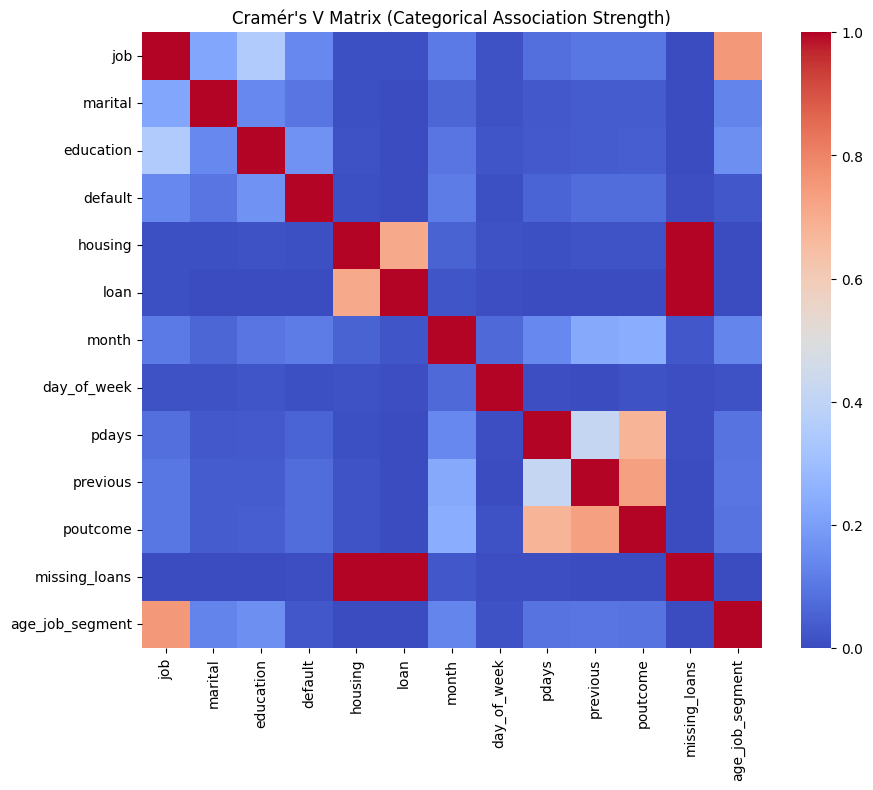

In [33]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramer_matrix.loc[c1, c2] = 1.0
        else:
            cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(10,8))
sns.heatmap(cramer_matrix.astype(float), cmap='coolwarm', annot=False)
plt.title("Cramér's V Matrix (Categorical Association Strength)")
plt.show()


In [34]:
df["previous_contact_status"] = np.where(df["poutcome"] == "success", "success",
                                         np.where(df["previous"] == "never_contacted", "never", "other"))
df.drop(columns=['poutcome', 'previous', 'pdays', 'missing_loans'], inplace=True)

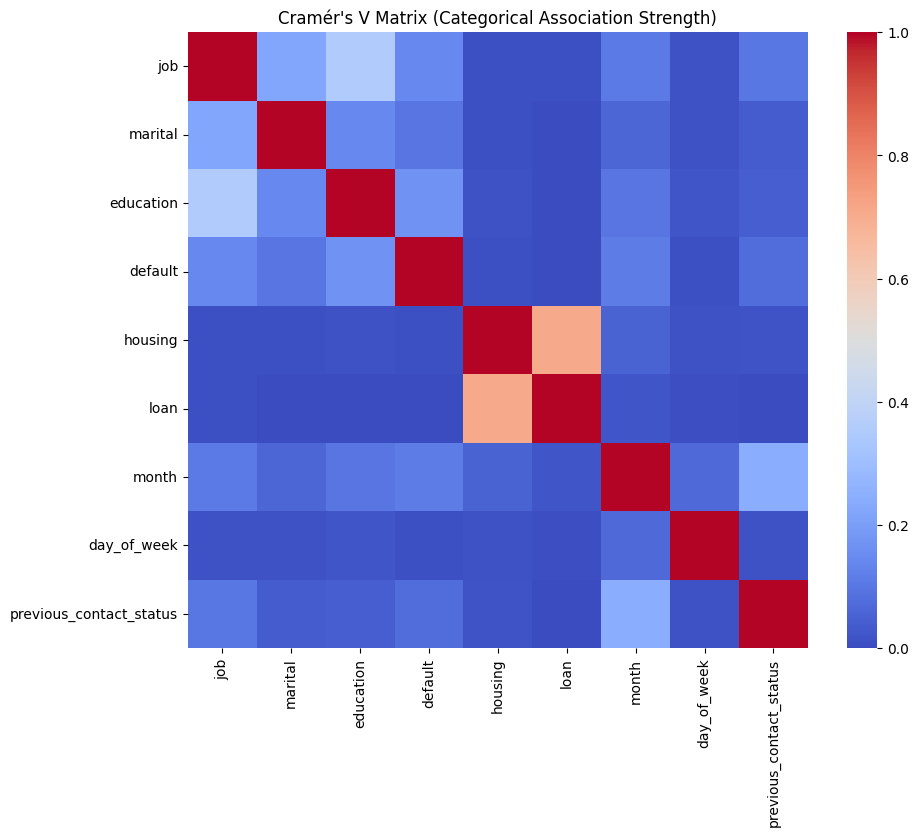

In [35]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 
            'loan', 'month', 'day_of_week', 'previous_contact_status']

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramer_matrix.loc[c1, c2] = 1.0
        else:
            cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

plt.figure(figsize=(10,8))
sns.heatmap(cramer_matrix.astype(float), cmap='coolwarm', annot=False)
plt.title("Cramér's V Matrix (Categorical Association Strength)")
plt.show()

In [36]:
def drop_multicollinear_columns(X, threshold=0.9999):
    """
    Automatically drops columns that are:
    1. Constant or duplicate
    2. Perfectly or near-perfectly correlated (>|threshold|)
    """
    X = X.copy()

    # Drop constant columns
    nunique = X.nunique()
    constant_cols = nunique[nunique <= 1].index.tolist()
    if constant_cols:
        print(f"Dropping constant columns: {constant_cols}")
        X = X.drop(columns=constant_cols)

    # Drop duplicate columns
    X = X.loc[:, ~X.T.duplicated()]

    # Compute correlation matrix
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find columns with correlation >= threshold
    to_drop = [column for column in upper.columns if any(upper[column] >= threshold)]
    if to_drop:
        print(f"Dropping highly correlated columns (>|{threshold}|): {to_drop}")
        X = X.drop(columns=to_drop)

    print(f"Remaining columns: {len(X.columns)}")
    return X


In [37]:
df_ = df.copy()
target_col = "y"                 
df_ = df.dropna(subset=[target_col]).copy()  

X = df_.drop(columns=[target_col])
y = df['y'].astype(str).str.lower().map({'yes': 1, 'no': 0})

X_encoded = pd.get_dummies(X, drop_first=True, dtype=float)

X_clean = drop_multicollinear_columns(X_encoded, threshold=0.9999)

Remaining columns: 51


## Scale continuous data

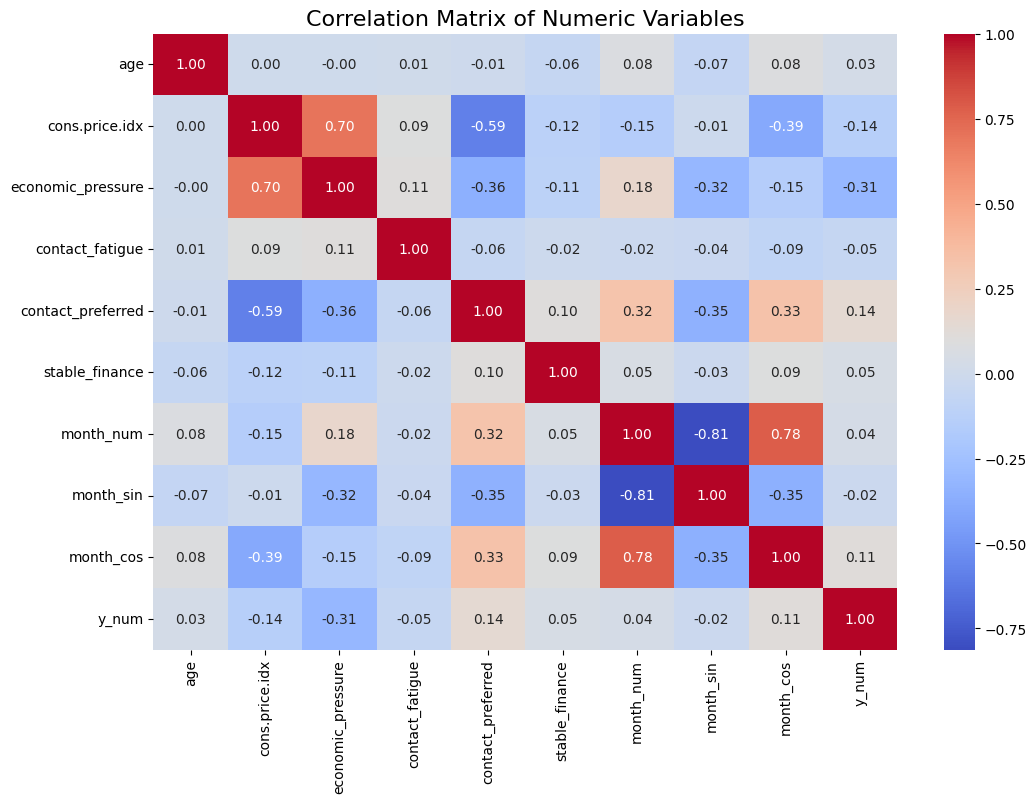

In [38]:
from sklearn.preprocessing import StandardScaler

df['y_num'] = df['y'].map({'no': 0, 'yes': 1})

df.drop(columns=['campaign'], inplace=True)

continuous_data = df.select_dtypes(include=['float64', 'int64'])

num_cols = X_clean.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()
X_clean[num_cols] = scaler.fit_transform(X_clean[num_cols])

# Compute the correlation matrix
correlation_matrix = continuous_data.corr()# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix of Numeric Variables", fontsize=16)
plt.show()


In [39]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# stratify=y to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.20, random_state=1, stratify=y
)
print(f'y train shape: {y_train.shape}, y test shape: {y_test.shape}')



y train shape: (32934,), y test shape: (8234,)


# MODELING

## Logistic regression (baseline model)

In [40]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

log_reg = LogisticRegression(C=0.01, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(log_reg, X_train_res, y_train_res,
                            cv=cv, scoring='recall', n_jobs=-1)

print("Cross-validated Recall Scores:", cv_scores)
print("Mean Recall:", np.mean(cv_scores))


Cross-validated Recall Scores: [0.66347305 0.6603935  0.67767322 0.65776865 0.6528657 ]
Mean Recall: 0.6624348252746486


In [41]:
from sklearn.metrics import roc_curve

y_prob = log_reg.fit(X_train_res, y_train_res).predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]

y_pred = (y_prob > optimal_tau).astype(int)

In [42]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\n=== Confusion Matrix: ===\n", confusion_matrix(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7307
           1       0.35      0.64      0.45       927

    accuracy                           0.83      8234
   macro avg       0.65      0.75      0.67      8234
weighted avg       0.88      0.83      0.85      8234

ROC-AUC: 0.7887058839855798

=== Confusion Matrix: ===
 [[6198 1109]
 [ 331  596]]


### Generalised linear model (Module 6)

In [44]:
from sklearn.model_selection import KFold
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score, recall_score
from imblearn.over_sampling import SMOTE
import statsmodels.api as sm

X_glm = sm.add_constant(X_clean, has_constant='add')
y = y.astype(int)

n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy='auto')

params = []
validation_scores = []
y_true_all = []
y_pred_all = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_glm, y), start=1):
    X_train, X_valid = X_glm.iloc[train_idx], X_glm.iloc[test_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[test_idx]

    # Apply SMOTE to the training fold only
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Fit GLM (logit link, Binomial family) using MLE
    family = sm.families.Binomial(sm.families.links.logit())
    model = sm.GLM(y_train_res, X_train_res, family=family)
    result = model.fit()

    # Save parameters for later averaging
    params.append(result.params)

    # Predict on original validation data
    y_pred_prob = result.predict(X_valid)
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    y_true_all.extend(y_valid.tolist())
    y_pred_all.extend(y_pred_class.tolist())

    # Metrics
    logloss = log_loss(y_valid, y_pred_prob)
    roc = roc_auc_score(y_valid, y_pred_prob)
    acc = accuracy_score(y_valid, y_pred_class)
    recall = recall_score(y_valid, y_pred_class)

    validation_scores.append({
        "Fold": fold,
        "LogLoss": logloss,
        "ROC_AUC": roc,
        "Accuracy": acc,
        "Recall": recall
    })

    print(f"Fold {fold}: LogLoss={logloss:.4f} | ROC_AUC={roc:.3f} | Acc={acc:.3f} | Recall={recall:.3f}")

# ---- Aggregate results ----
validation_scores_df = pd.DataFrame(validation_scores)
mean_scores = validation_scores_df.mean(numeric_only=True)

print("\n=== Cross-Validation Summary ===")
for metric, value in mean_scores.items():
    print(f"Mean {metric}: {value:.4f}")

# ---- Model summary from last fold ----
summary_table = result.summary(xname=X_glm.columns.tolist())
print("\nModel Summary (Last Fold):")
print(summary_table)


Fold 1: LogLoss=5.5006 | ROC_AUC=0.608 | Acc=0.678 | Recall=0.498
Fold 2: LogLoss=4.8285 | ROC_AUC=0.621 | Acc=0.559 | Recall=0.520
Fold 3: LogLoss=14.0600 | ROC_AUC=0.545 | Acc=0.449 | Recall=0.510
Fold 4: LogLoss=0.5283 | ROC_AUC=0.774 | Acc=0.793 | Recall=0.641
Fold 5: LogLoss=0.8712 | ROC_AUC=0.696 | Acc=0.674 | Recall=0.605

=== Cross-Validation Summary ===
Mean Fold: 3.0000
Mean LogLoss: 5.1577
Mean ROC_AUC: 0.6487
Mean Accuracy: 0.6306
Mean Recall: 0.5548

Model Summary (Last Fold):
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                58426
Model:                            GLM   Df Residuals:                    58377
Model Family:                Binomial   Df Model:                           48
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Sun, 26 Oc

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n=== Overall Classification Report (Out-of-Fold) ===")
print(classification_report(y_true_all, y_pred_all))

print("ROC-AUC:", roc_auc_score(y_true_all, y_pred_all))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_all, y_pred_all))



=== Overall Classification Report (Out-of-Fold) ===
              precision    recall  f1-score   support

           0       0.92      0.64      0.75     36531
           1       0.16      0.55      0.25      4637

    accuracy                           0.63     41168
   macro avg       0.54      0.60      0.50     41168
weighted avg       0.83      0.63      0.70     41168

ROC-AUC: 0.597432482462052

Confusion Matrix:
[[23387 13144]
 [ 2065  2572]]


## Non-parametric models
### Decision tree

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
tree = DecisionTreeClassifier(random_state=42)

In [47]:
X_train_tree = X_train.drop(columns=['const'], errors='ignore')
X_test_tree = X_test.drop(columns=['const'], errors='ignore')

pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', tree)
])

param_grid = {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 4, 6],
    'model__max_features': [None, 'sqrt']
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = RandomizedSearchCV(estimator=pipe,
                           param_distributions=param_grid,
                           n_iter=20,
                           scoring='recall',
                           cv=cv,
                           n_jobs=-1,
                           verbose=1,
                           random_state=42)

grid_search.fit(X_train_tree, y_train)
print('Best parameters found: ', grid_search.best_params_)
print('Best recall score: ', grid_search.best_score_)

best_tree = grid_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'model__min_samples_split': 10, 'model__min_samples_leaf': 6, 'model__max_features': 'sqrt', 'model__max_depth': 5, 'model__criterion': 'log_loss'}
Best recall score:  0.6386245219022877


In [48]:
y_prob_dt = best_tree.predict_proba(X_test_tree)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]

y_pred_dt = (y_prob > optimal_tau).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_dt))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("\n=== Confusion Matrix: ===\n", confusion_matrix(y_test, y_pred_dt))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.78      0.86      7307
           1       0.29      0.68      0.40       927

    accuracy                           0.77      8234
   macro avg       0.62      0.73      0.63      8234
weighted avg       0.88      0.77      0.81      8234

ROC-AUC: 0.7455573404291285

=== Confusion Matrix: ===
 [[5722 1585]
 [ 293  634]]


### Random forest

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier()

pipe = Pipeline([
    ('smote', smote),
    ('model', rf)])

param_grid_rf = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': [None, 'sqrt'],
    'model__class_weight': ['balanced'],
    'model__bootstrap': [True]
}

ran_search_rf = RandomizedSearchCV(estimator=pipe, 
                              param_distributions=param_grid_rf,
                              n_iter=20,
                              scoring='recall', 
                              cv=5, 
                              n_jobs=-1, 
                              verbose=1,
                              random_state=42)

ran_search_rf.fit(X_train_tree, y_train)
print('Best parameters found: ', ran_search_rf.best_params_)
print('Best recall score: ', ran_search_rf.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 10, 'model__class_weight': 'balanced', 'model__bootstrap': True}
Best recall score:  0.2244620047629357


In [50]:
best_rf = ran_search_rf.best_estimator_
y_prob_rf = best_rf.predict_proba(X_test_tree)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]

y_pred_rf = (y_prob > optimal_tau).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\n=== Confusion Matrix: ===\n", confusion_matrix(y_test, y_pred_rf))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.41      0.58      7307
           1       0.16      0.86      0.27       927

    accuracy                           0.46      8234
   macro avg       0.56      0.64      0.42      8234
weighted avg       0.87      0.46      0.54      8234

ROC-AUC: 0.828395921276003

=== Confusion Matrix: ===
 [[3019 4288]
 [ 126  801]]


### Gradient boosting

In [51]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier()

pipe = Pipeline([
    ('smote', smote),
    ('model', gb)
])

param_grid_gb = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_features': [None, 'sqrt']
}

ran_search_gb = RandomizedSearchCV(
                    estimator=pipe,
                    param_distributions=param_grid_gb,
                    n_iter=20,
                    scoring='recall',
                    cv=5,
                    n_jobs=-1,                        
                    verbose=1,
                    random_state=42
)

ran_search_gb.fit(X_train_tree, y_train)
print('Best parameters found: ', ran_search_gb.best_params_)
print('Best recall score: ', ran_search_gb.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 3, 'model__learning_rate': 0.01}
Best recall score:  0.4199123186836978


In [52]:
best_gb = ran_search_gb.best_estimator_   
y_prob_gb = best_gb.predict_proba(X_test_tree)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]

y_pred_gb = (y_prob > optimal_tau).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_gb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("\n=== Confusion Matrix: ===\n", confusion_matrix(y_test, y_pred_gb))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.81      0.88      7307
           1       0.31      0.67      0.42       927

    accuracy                           0.80      8234
   macro avg       0.63      0.74      0.65      8234
weighted avg       0.88      0.80      0.83      8234

ROC-AUC: 0.7859507714447984

=== Confusion Matrix: ===
 [[5935 1372]
 [ 307  620]]


## XGBoost

In [53]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipe = Pipeline([('smote', smote),
                 ('model', xgb)
                ])

param_grid_xgb = {
    'model__n_estimators': [100, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.3],
    'model__reg_lambda': [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X_train_tree, y_train)
print('Best parameters found: ', xgb_search.best_params_)
print('Best recall score: ', xgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:10:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:10:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:10:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:10:33] WARN

Best parameters found:  {'model__subsample': 0.85, 'model__reg_lambda': 10, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}
Best recall score:  0.2636703471169806


In [54]:
best_xgb = xgb_search.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test_tree)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]

y_pred_xgb = (y_prob_xgb > optimal_tau).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\n=== Confusion Matrix: ===\n", confusion_matrix(y_test, y_pred_xgb))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7307
           1       0.36      0.64      0.46       927

    accuracy                           0.83      8234
   macro avg       0.65      0.75      0.68      8234
weighted avg       0.88      0.83      0.85      8234

ROC-AUC: 0.795074295177933

=== Confusion Matrix: ===
 [[6241 1066]
 [ 331  596]]


## CatBoost

In [55]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='Recall',
    random_seed=42,
    verbose=0
)

pipe = Pipeline([('smote', smote), ('model', cat)])

param_grid_cat = {
    'model__iterations': [300, 500, 800],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [4, 6, 8],
    'model__l2_leaf_reg': [1, 3, 5, 7],
    'model__bagging_temperature': [0.5, 1, 2],
    'model__border_count': [32, 64, 128]
}

cat_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid_cat,
    n_iter=20,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

cat_search.fit(X_train_tree, y_train)
print('Best parameters found: ', cat_search.best_params_)
print('Best recall score: ', cat_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 3, 'model__iterations': 300, 'model__depth': 4, 'model__border_count': 128, 'model__bagging_temperature': 2}
Best recall score:  0.2400155156238724


In [56]:
best_cb = cat_search.best_estimator_
y_pred_cb = best_cb.predict(X_test_tree)
y_prob_cb = best_cb.predict_proba(X_test_tree)[:, 1]

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_cb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_cb))
print("\n=== Confusion Matrix: ===\n", confusion_matrix(y_test, y_pred_cb))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7307
           1       0.44      0.53      0.48       927

    accuracy                           0.87      8234
   macro avg       0.69      0.72      0.71      8234
weighted avg       0.88      0.87      0.88      8234

ROC-AUC: 0.791458117698018

=== Confusion Matrix: ===
 [[6692  615]
 [ 435  492]]


In [57]:
from sklearn.ensemble import VotingClassifier
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tree, y_train)

# Refit each tuned model on full balanced data
best_tree.fit(X_train_res, y_train_res)
best_rf.fit(X_train_res, y_train_res)
best_gb.fit(X_train_res, y_train_res)
best_xgb.fit(X_train_res, y_train_res)
best_cb.fit(X_train_res, y_train_res)

ensemble = VotingClassifier(
    estimators=[
        ("DecisionTree", best_tree),
        ("RandomForest", best_rf),
        ("GradientBoost", best_gb),
        ("XGBoost", best_xgb),
        ("CatBoost", best_cb)
    ],
    voting='soft',   # average predicted probabilities
    n_jobs=-1
)

ensemble.fit(X_train_tree, y_train)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [18:18:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


VotingClassifier(estimators=[('DecisionTree',
                              Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                              ('model',
                                               DecisionTreeClassifier(criterion='log_loss',
                                                                      max_depth=5,
                                                                      max_features='sqrt',
                                                                      min_samples_leaf=6,
                                                                      min_samples_split=10,
                                                                      random_state=42))])),
                             ('RandomForest',
                              Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                              ('model',
                                               RandomForestClassifier(class_weight=...
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=5,
                                                             max_leaves=None,
                                                             min_child_weight=1,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=100,
                                                             n_jobs=None,
                                                             num_parallel_tree=None, ...))])),
                             ('CatBoost',
                              Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                              ('model',
                                               <catboost.core.CatBoostClassifier object at 0x31a188e90>)]))],
                 n_jobs=-1, voting='soft')

In [58]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_prob_ensemble = ensemble.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_ensemble)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]
y_pred_ensemble = (y_prob_ensemble > optimal_tau).astype(int)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_ensemble))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7307
           1       0.38      0.63      0.48       927

    accuracy                           0.84      8234
   macro avg       0.67      0.75      0.69      8234
weighted avg       0.89      0.84      0.86      8234

ROC-AUC: 0.8062529332677256
Confusion Matrix:
 [[6354  953]
 [ 339  588]]


## Neural network

In [59]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import Recall, Precision, AUC
from sklearn.preprocessing import StandardScaler


In [60]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(
        units=hp.Int('units_input', min_value=64, max_value=512, step=64),
        activation='relu',
        input_dim=X_train_tree.shape[1]))

    model.add(Dropout(hp.Float('dropout_input', 0.2, 0.5, step=0.1)))

    model.add(Dense(
        units=hp.Int('units_hidden', min_value=32, max_value=256, step=32),
        activation='relu'))
    model.add(Dropout(hp.Float('dropout_hidden', 0.2, 0.5, step=0.1)))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')),
        loss='binary_crossentropy',
        metrics=[
        Recall(name='recall'), 
        Precision(name='precision'), 
        AUC(name='auc')])
    return model

In [61]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tree, y_train)

tuner = kt.RandomSearch(
    build_model,
    objective='val_recall',          # Focus on recall (for class imbalance)
    max_trials=5,                   # Number of combinations to try
    executions_per_trial=1,          # Train each configuration once
    overwrite=True,
    directory='tuner_results',
    project_name='nn_campaign_tuning'
)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner.search(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



Trial 5 Complete [00h 02m 08s]
val_recall: 0.931456446647644

Best val_recall So Far: 0.9728735089302063
Total elapsed time: 00h 09m 33s


In [62]:
best_model_nn = tuner.get_best_models(num_models=1)[0]
best_hps_nn = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print(f"Input units: {best_hps_nn.get('units_input')}")
print(f"Hidden units: {best_hps_nn.get('units_hidden')}")
print(f"Dropout input: {best_hps_nn.get('dropout_input')}")
print(f"Dropout hidden: {best_hps_nn.get('dropout_hidden')}")
print(f"Learning rate: {best_hps_nn.get('learning_rate')}")


Best hyperparameters found:
Input units: 384
Hidden units: 224
Dropout input: 0.2
Dropout hidden: 0.4
Learning rate: 0.0005070370705614628


In [63]:
y_prob_nn = best_model_nn.predict(X_test_tree).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_prob_nn)
optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
optimal_tau = thresholds[optimal_idx]
y_pred_nn = (y_prob_nn > optimal_tau).astype(int)

print("\n=== Neural Network (Tuned) Evaluation ===")
print(classification_report(y_test, y_pred_nn))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_nn):.3f}")
print(confusion_matrix(y_test, y_pred_nn))


258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step

=== Neural Network (Tuned) Evaluation ===
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      7307
           1       0.54      0.87      0.67       927

    accuracy                           0.90      8234
   macro avg       0.76      0.89      0.81      8234
weighted avg       0.93      0.90      0.91      8234

ROC-AUC: 0.940
[[6621  686]
 [ 118  809]]


In [66]:
from sklearn.metrics import precision_score
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': best_tree,
    'Random Forest': best_rf,
    'XGBoost': best_xgb,
    'CatBoost': best_cb,
    'Ensemble voting': ensemble,
    'Neural Network': best_model_nn
}

results = []


for name, model in models.items():
    y_pred = model.predict(X_test_tree)

    # Handle probability prediction safely
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_tree)[:, 1]
    else:
        # For Keras Sequential models: predict() already gives probability
        y_proba = model.predict(X_test_tree).ravel()

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    optimal_idx = np.argmax(tpr - fpr)  # Maximizing Sensitivity - Specificity
    optimal_tau = thresholds[optimal_idx]
    y_pred = (y_proba > optimal_tau).astype(int)

    results.append({
        'Model': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Accuracy': accuracy_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results).sort_values(by='Recall', ascending=False)
df_results = df_results.round(2)
display(df_results)


258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step


,Model,Recall,Precision,F1,ROC-AUC,Accuracy
6,Neural Network,0.87,0.54,0.67,0.94,0.90
2,Random Forest,0.68,0.39,0.50,0.83,0.84
0,Logistic Regression,0.64,0.35,0.45,0.79,0.83
3,XGBoost,0.64,0.36,0.46,0.80,0.83
4,CatBoost,0.64,0.35,0.45,0.79,0.83
1,Decision Tree,0.64,0.29,0.40,0.75,0.78
5,Ensemble voting,0.63,0.38,0.48,0.81,0.84


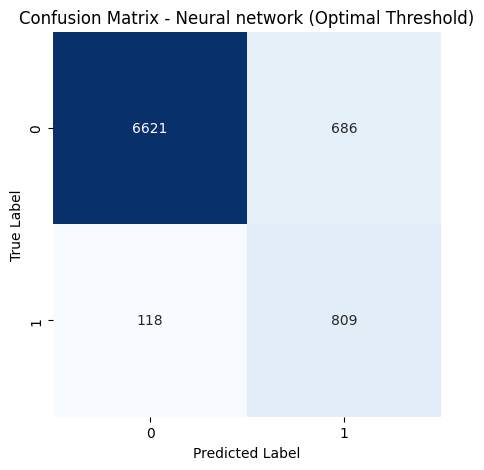

In [67]:
# Plot confusion matrix for Logistic Regression model
cm = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural network (Optimal Threshold)")

plt.show()

In [68]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# define a lightweight prediction function
def predict_fn(X):
    return best_model_nn.predict(X).ravel()

# use small random samples for efficiency
background = X_train_tree.sample(100, random_state=42)
X_sample   = X_test_tree.sample(200, random_state=42)

explainer = shap.KernelExplainer(predict_fn, background)
shap_values_nn = explainer.shap_values(X_sample, nsamples=100)

# shap_values now has shape (200, 51)
print(np.array(shap_values_nn).shape)




4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 357us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

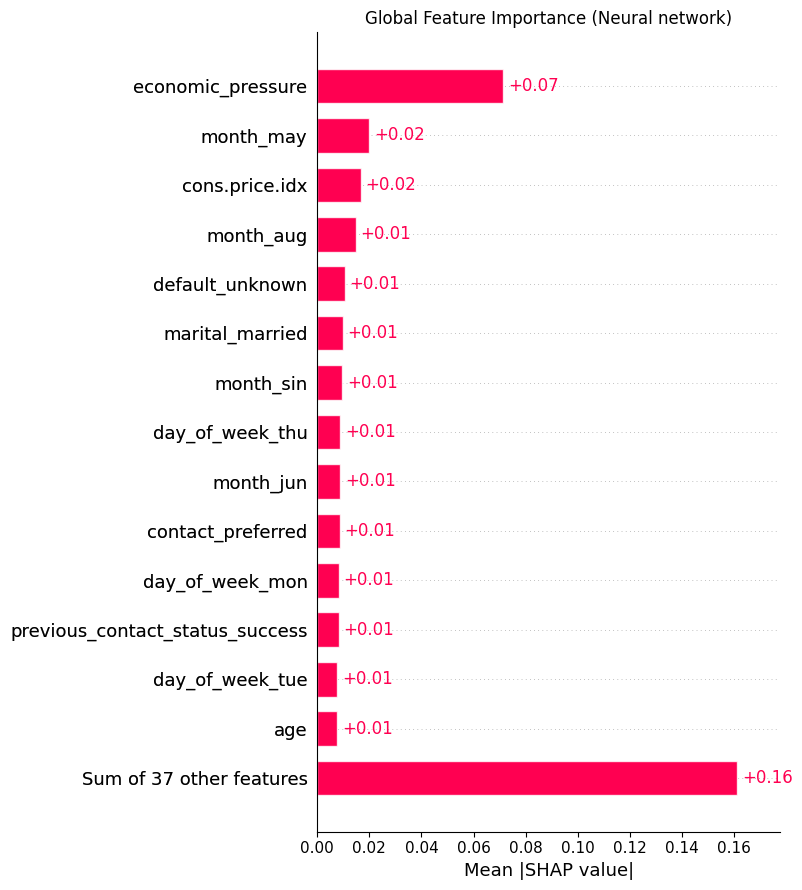

In [69]:
# --- Bar plot ---
expected_value = explainer.expected_value
if np.isscalar(expected_value):  # if it's a float, repeat it for each row
    expected_value = np.repeat(expected_value, shap_values_nn.shape[0])

shap_exp = shap.Explanation(values = shap_values_nn,
    base_values = expected_value,
    data = X_sample,
    feature_names = X_sample.columns
)

plt.figure(figsize=(8,6))
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title('Global Feature Importance (Neural network)')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.show()


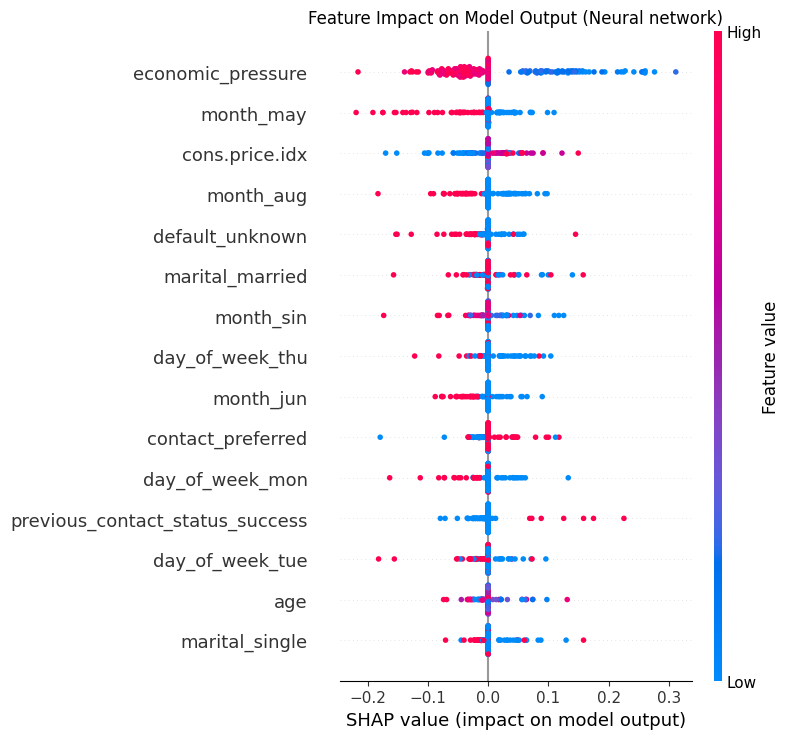

In [70]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_nn, X_sample, plot_type='dot', max_display=15, show=False)
plt.title('Feature Impact on Model Output (Neural network)')
plt.tight_layout()
plt.show()

# Feature importance for Random forest model

In [71]:
rf_model = best_rf.named_steps['model']
explainer = shap.Explainer(rf_model, X_test_tree)
shap_values = explainer(X_test_tree)

100%|===================| 16453/16468 [06:17<00:00]        

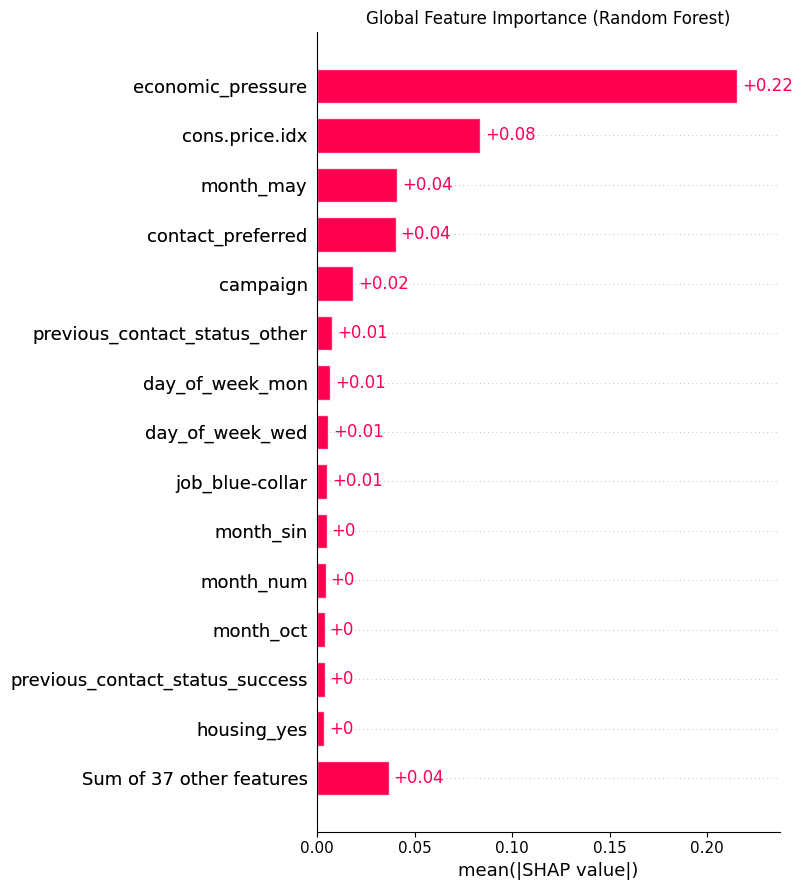

In [72]:
shap_positive = shap_values[:, :, 1]

plt.figure(figsize=(8,6))
shap.plots.bar(shap_positive, max_display=15, show=False)
plt.title('Global Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

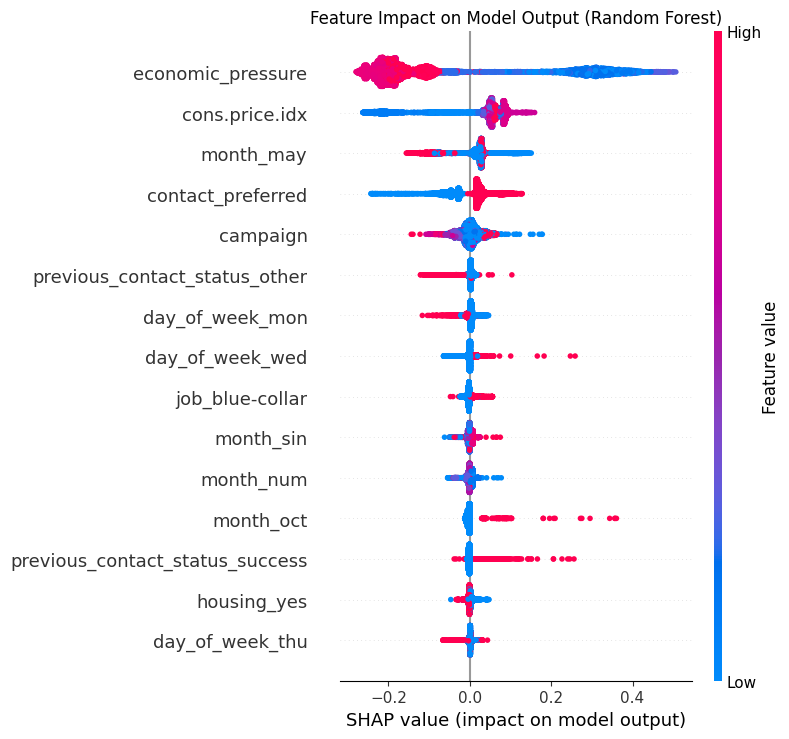

In [73]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_positive, X_test_tree, plot_type='dot', max_display=15, show=False)
plt.title('Feature Impact on Model Output (Random Forest)')
plt.tight_layout()
plt.show()

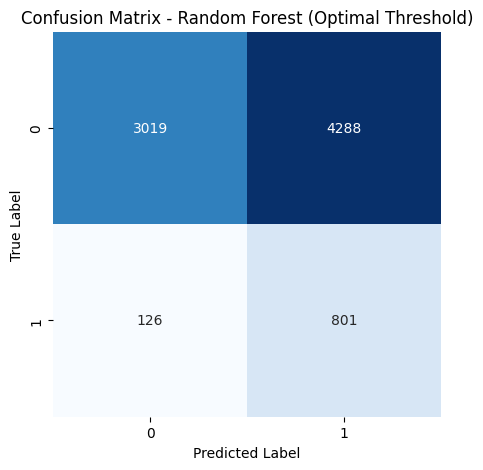

In [74]:
# Plot confusion matrix for Logistic Regression model
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest (Optimal Threshold)")

plt.show()